In [420]:

# NOTE
# Use training, test, validation sets (done)

# Task 1.1
# Apply test data. Calculate differences between original and reconstructed patches
# With beta and with no beta (done)

# Task 1.2
# Plot latent vector distribution for the mean matrix (DONE)

# Task 1.3 
# Plot the curve for KL divergence (DONE)

# Task 1.4
# Filter out empty patches (DONE)


In [421]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec

In [422]:
# References
# https://datatas.com/how-to-use-variational-autoencoders-for-large-scale-data-compression/

In [423]:
# Task:
# Create plot with train loss, test loss, valid loss
# Plots with different betas
# Check what error curves are good for VAE
# Plot before and after plots

In [424]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [425]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    # print(encoded_width, encoded_height, np.log2(num_embeddings))
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount * encoded_patch_bits)

def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    total_bits = _get_total_hit_bits(n_hits_total)
    
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    # event_patches_adcs = [
    #     event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
    #     for event_patch_flat in event_patches_adcs_flat
    # ]
    return len(event_patches_adcs_flat)
    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [426]:
def _get_compression_ratio_vae(n_hits_total: int, patch_amount: int, z: torch.tensor) -> float:
    total_hit_bits = _get_total_hit_bits(n_hits_total)    
    z_item_amount = z[0][0].numel()  
       
    z_bytes_per_element = z.element_size()  
    z_total_bytes = z_item_amount * z_bytes_per_element 
    z_1sp_total_bits = z_total_bytes * 8
    total_encoded_patch_bits = patch_amount * z_1sp_total_bits
    ratio = total_hit_bits / total_encoded_patch_bits    
    
    return {
        "compression_ratio" : ratio,
        "total_hits" : n_hits_total,
        "total_hit_bits" : total_hit_bits,
        "total_patch_amount" : patch_amount,
        "encoded_patch_bits" : z_1sp_total_bits,
        "total_encoded_patch_bits" : total_encoded_patch_bits,
    }

In [427]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 266.29it/s]


In [428]:
batch_size = 64
# beta = 0
beta = 1e-5
learning_rate = 1e-3
num_epochs = 80
channels = 1
latent_dim = 128

# logs
LOG_EVERY = 10


In [429]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [430]:
mse = MeanSquaredError()
mse = mse.to(device)

In [431]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [432]:
event_train = events_train[:SELECTED_EVENTS][0]

In [433]:
patch_amount = _get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [434]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [435]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")


# EXAMPLE with events test
# train_loader = DataLoader(
#     dataset=event_dataset, 
#     batch_size=batch_size
# )

# # Test data preparation
# events_test_loaders = []
# for event_test in events_test:
#     event_dataset = PixelPatchesDataset(event_test, transform)

#     event_test_loader = DataLoader(
#         dataset=event_dataset, 
#         batch_size=batch_size
#     )
#     events_test_loaders.append(event_test_loader)

Training set size: 12685
Validation set size: 1585
Test set size: 1587


In [436]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor, 
    mu: torch.tensor, 
    logvar: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    
    # KL_divergence
    kl_loss = -0.5 * (
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    
    kl_loss = kl_loss.mean()
    
    return (
        recon_loss + beta * kl_loss,
        recon_loss,
        beta,
        kl_loss
    )

In [437]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
        )
        # self.flatten = nn.Flatten()
        self.fc_mean = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        self.fc_log_var = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_mean = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )
        torch.nn.init.xavier_uniform_(self.fc_mean.weight)
        
        # self.fc_log_var = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )        
        torch.nn.init.xavier_uniform_(self.fc_log_var.weight)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        x_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        z_log_mean = self.fc_mean(x_encoded)
        z_log_var = self.fc_log_var(x_encoded)
        
        self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        # self.z_log_var = torch.clamp(z_log_var, min=-8, max=1)
        self.z_log_var = torch.tanh(z_log_var) * 8
        
        # sample a latent vector using the reparameterization trick
        
        z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        output = self.decoder(z)
        
        return output, self.z_log_mean, self.z_log_var, z

In [438]:
model = VAE(
    hidden_channels=64, 
    kernel_size = 4,
    slope=0.01
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 494.05it/s, Loss=0.0495]


Epoch [1/80]Average Loss: BCE = 0.0762, MSE = 0.009735250974251847, KL = 14.307511159523049
Average validation set BCE loss: 0.8371298241615296
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=0.0045, std=0.5447 | logvar: mean=-6.1354, std=1.4390
Before compression
Shape: (64, 8, 8)


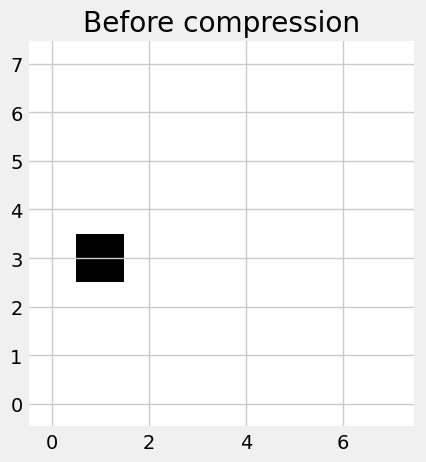

After compression
Shape: (1, 8, 8)


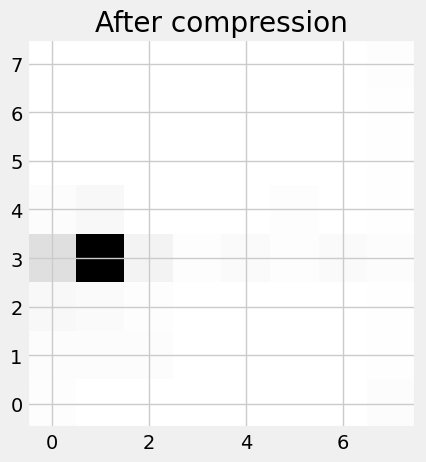

Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 507.79it/s, Loss=0.0298]


Epoch [2/80]Average Loss: BCE = 0.0370, MSE = 0.0027576621087155675, KL = 2.8846858458303326
Average validation set BCE loss: 0.46579292058944705
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 497.42it/s, Loss=0.0289]


Epoch [3/80]Average Loss: BCE = 0.0335, MSE = 0.0022524855744290215, KL = 3.023902229328251
Average validation set BCE loss: 0.3308163332939148
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 4/80: 100%|██████████| 199/199 [00:00<00:00, 501.02it/s, Loss=0.0425]


...

Epoch [9/80]Average Loss: BCE = 0.0297, MSE = 0.0015156462188370189, KL = 3.2368744569807197
Average validation set BCE loss: 0.21698752909898758
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 10/80: 100%|██████████| 199/199 [00:00<00:00, 506.83it/s, Loss=0.0334]


Epoch [10/80]Average Loss: BCE = 0.0294, MSE = 0.0014277612357564157, KL = 3.251294737485186
Average validation set BCE loss: 0.2136859840154648
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 11/80: 100%|██████████| 199/199 [00:00<00:00, 507.75it/s, Loss=0.0307]


Epoch [11/80]Average Loss: BCE = 0.0293, MSE = 0.0013975408603905245, KL = 3.2670867095640554
Average validation set BCE loss: 0.1999221622943878
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0126, std=0.7520 | logvar: mean=-6.9612, std=1.0358
Before compression
Shape: (64, 8, 8)


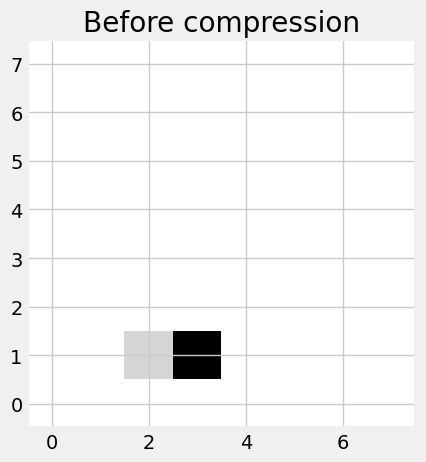

After compression
Shape: (1, 8, 8)


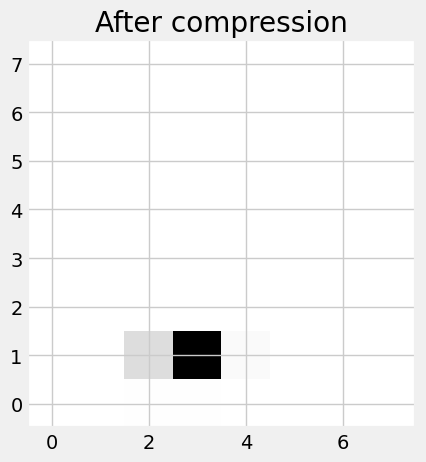

Epoch 12/80: 100%|██████████| 199/199 [00:00<00:00, 503.92it/s, Loss=0.0341]


Epoch [12/80]Average Loss: BCE = 0.0291, MSE = 0.0013239849978898789, KL = 3.277950742136893
Average validation set BCE loss: 0.1891256406903267
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 13/80: 100%|██████████| 199/199 [00:00<00:00, 510.10it/s, Loss=0.021] 


Epoch [13/80]Average Loss: BCE = 0.0289, MSE = 0.0012809278124044812, KL = 3.2836090236452957
Average validation set BCE loss: 0.1948448497056961
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 14/80: 100%|██████████| 199/199 [00:00<00:00, 513.76it/s, Loss=0.0172]


...

Epoch [19/80]Average Loss: BCE = 0.0281, MSE = 0.000979530919301113, KL = 3.331357940357534
Average validation set BCE loss: 0.1849288049340248
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 20/80: 100%|██████████| 199/199 [00:00<00:00, 507.52it/s, Loss=0.0234]


Epoch [20/80]Average Loss: BCE = 0.0279, MSE = 0.0009252460445008292, KL = 3.336625632329203
Average validation set BCE loss: 0.1681119455397129
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 21/80: 100%|██████████| 199/199 [00:00<00:00, 503.20it/s, Loss=0.0299]


Epoch [21/80]Average Loss: BCE = 0.0278, MSE = 0.0008624502840561876, KL = 3.349281072616577
Average validation set BCE loss: 0.16216708108782768
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=0.0006, std=0.8005 | logvar: mean=-7.0322, std=1.0229
Before compression
Shape: (64, 8, 8)


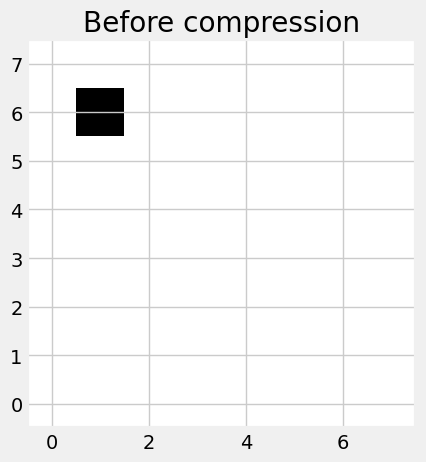

After compression
Shape: (1, 8, 8)


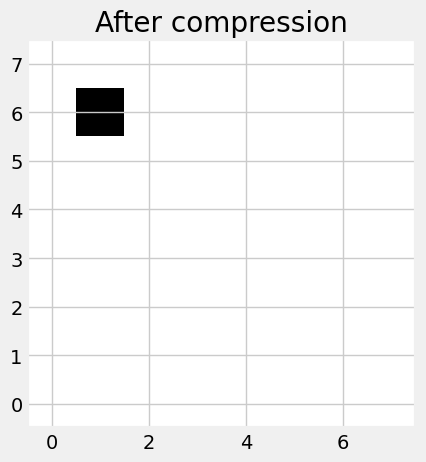

Epoch 22/80: 100%|██████████| 199/199 [00:00<00:00, 508.88it/s, Loss=0.0336]


Epoch [22/80]Average Loss: BCE = 0.0277, MSE = 0.0008425649747500505, KL = 3.354127290859893
Average validation set BCE loss: 0.1697700946033001
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 23/80: 100%|██████████| 199/199 [00:00<00:00, 506.06it/s, Loss=0.0203]


Epoch [23/80]Average Loss: BCE = 0.0276, MSE = 0.0008277890685449668, KL = 3.358929214765079
Average validation set BCE loss: 0.16359726279973985
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 24/80: 100%|██████████| 199/199 [00:00<00:00, 508.16it/s, Loss=0.0343]


...

Epoch [29/80]Average Loss: BCE = 0.0272, MSE = 0.0006778911291387625, KL = 3.3768730271401717
Average validation set BCE loss: 0.15755153551697731
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 505.98it/s, Loss=0.0234]


Epoch [30/80]Average Loss: BCE = 0.0271, MSE = 0.0006392556817408876, KL = 3.377942522566522
Average validation set BCE loss: 0.1528783717751503
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 509.61it/s, Loss=0.0219]


Epoch [31/80]Average Loss: BCE = 0.0271, MSE = 0.0006229141917215408, KL = 3.3805082874681482
Average validation set BCE loss: 0.16016895338892936
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0036, std=0.8549 | logvar: mean=-6.9902, std=1.0854
Before compression
Shape: (64, 8, 8)


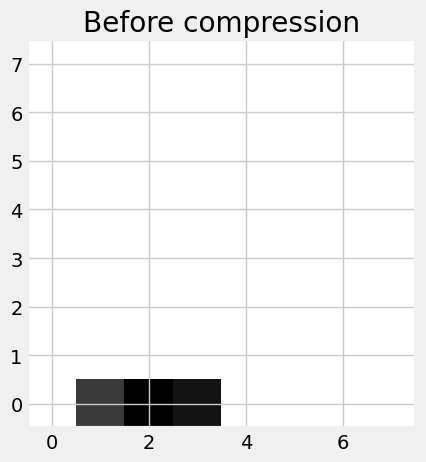

After compression
Shape: (1, 8, 8)


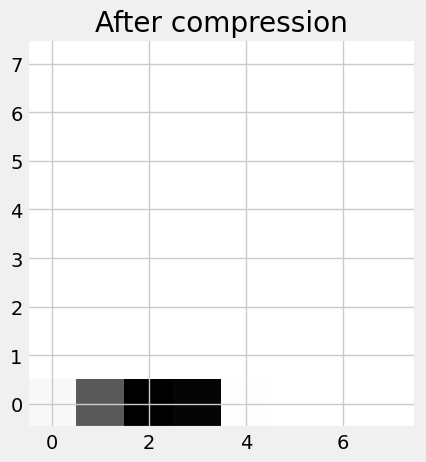

Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 503.05it/s, Loss=0.0268]


Epoch [32/80]Average Loss: BCE = 0.0271, MSE = 0.0006167901925281645, KL = 3.385039865072049
Average validation set BCE loss: 0.15672093003988266
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 496.74it/s, Loss=0.0296]


Epoch [33/80]Average Loss: BCE = 0.0270, MSE = 0.000591666461670556, KL = 3.3881625805667897
Average validation set BCE loss: 0.14874498307704925
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 34/80: 100%|██████████| 199/199 [00:00<00:00, 486.37it/s, Loss=0.0215]


...

Epoch [39/80]Average Loss: BCE = 0.0266, MSE = 0.0004423730836300198, KL = 3.4021411792716787
Average validation set BCE loss: 0.13403543308377266
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 40/80: 100%|██████████| 199/199 [00:00<00:00, 515.92it/s, Loss=0.0293]


Epoch [40/80]Average Loss: BCE = 0.0266, MSE = 0.0004337820809173056, KL = 3.4070064913687395
Average validation set BCE loss: 0.13375480487942695
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 41/80: 100%|██████████| 199/199 [00:00<00:00, 505.18it/s, Loss=0.0291]


Epoch [41/80]Average Loss: BCE = 0.0266, MSE = 0.00043987147134188186, KL = 3.411592429606759
Average validation set BCE loss: 0.14086084961891174
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0089, std=0.8761 | logvar: mean=-7.0367, std=1.0478
Before compression
Shape: (64, 8, 8)


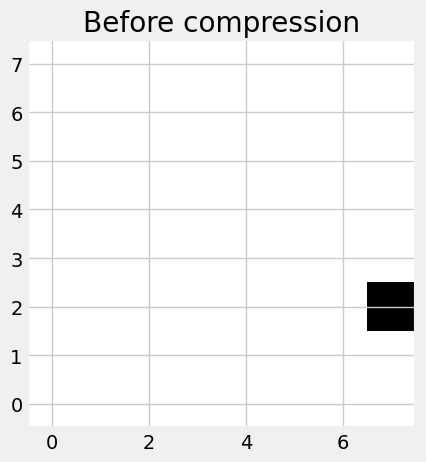

After compression
Shape: (1, 8, 8)


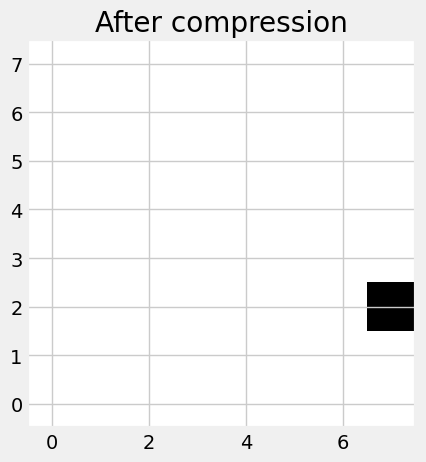

Epoch 42/80: 100%|██████████| 199/199 [00:00<00:00, 509.49it/s, Loss=0.0243]


Epoch [42/80]Average Loss: BCE = 0.0265, MSE = 0.0004117802793426842, KL = 3.41195781985719
Average validation set BCE loss: 0.13844965130090714
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 43/80: 100%|██████████| 199/199 [00:00<00:00, 506.14it/s, Loss=0.0219]


Epoch [43/80]Average Loss: BCE = 0.0264, MSE = 0.0003984741535038926, KL = 3.4100174268885475
Average validation set BCE loss: 0.13266482204198837
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 44/80: 100%|██████████| 199/199 [00:00<00:00, 509.95it/s, Loss=0.0235]


...

Epoch [49/80]Average Loss: BCE = 0.0263, MSE = 0.00032960637528145096, KL = 3.4121431920995664
Average validation set BCE loss: 0.132061847448349
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 50/80: 100%|██████████| 199/199 [00:00<00:00, 515.97it/s, Loss=0.029] 


Epoch [50/80]Average Loss: BCE = 0.0262, MSE = 0.00029731367322167, KL = 3.410694232538118
Average validation set BCE loss: 0.13021260008215904
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 51/80: 100%|██████████| 199/199 [00:00<00:00, 498.71it/s, Loss=0.021] 


Epoch [51/80]Average Loss: BCE = 0.0261, MSE = 0.00028315826671475303, KL = 3.414245068727426
Average validation set BCE loss: 0.13129676058888434
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0040, std=0.8959 | logvar: mean=-7.0030, std=1.0799
Before compression
Shape: (64, 8, 8)


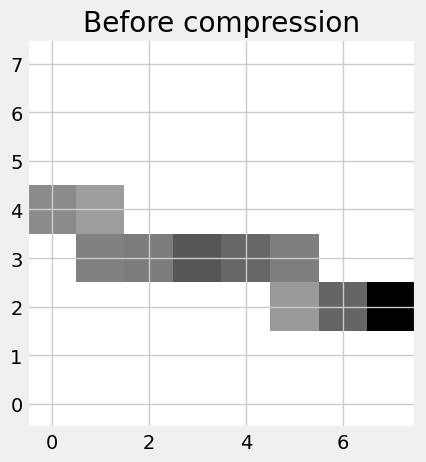

After compression
Shape: (1, 8, 8)


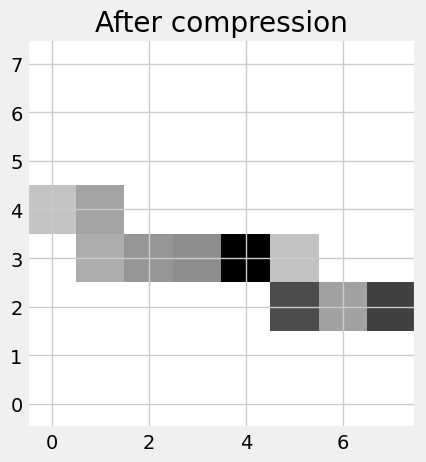

Epoch 52/80: 100%|██████████| 199/199 [00:00<00:00, 508.61it/s, Loss=0.0226]


Epoch [52/80]Average Loss: BCE = 0.0261, MSE = 0.0002585654283713446, KL = 3.4122761769510395
Average validation set BCE loss: 0.10843184366822242
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 53/80: 100%|██████████| 199/199 [00:00<00:00, 518.14it/s, Loss=0.017] 


Epoch [53/80]Average Loss: BCE = 0.0260, MSE = 0.0002443534087351097, KL = 3.405209153141808
Average validation set BCE loss: 0.12831395074725152
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 54/80: 100%|██████████| 199/199 [00:00<00:00, 506.34it/s, Loss=0.0248]


...

Epoch [59/80]Average Loss: BCE = 0.0256, MSE = 9.492276123509598e-05, KL = 3.398556705695301
Average validation set BCE loss: 0.0943202818930149
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 523.88it/s, Loss=0.0192]


Epoch [60/80]Average Loss: BCE = 0.0256, MSE = 8.119204387331414e-05, KL = 3.3988796909849848
Average validation set BCE loss: 0.08991402104496955
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 512.19it/s, Loss=0.0165]


Epoch [61/80]Average Loss: BCE = 0.0255, MSE = 7.908981290222356e-05, KL = 3.39961801461838
Average validation set BCE loss: 0.09073464706540108
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0084, std=0.8808 | logvar: mean=-6.9950, std=1.0481
Before compression
Shape: (64, 8, 8)


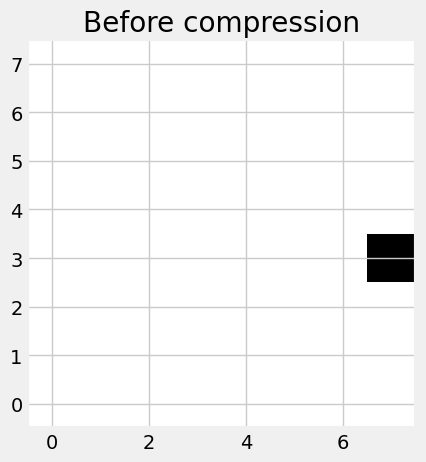

After compression
Shape: (1, 8, 8)


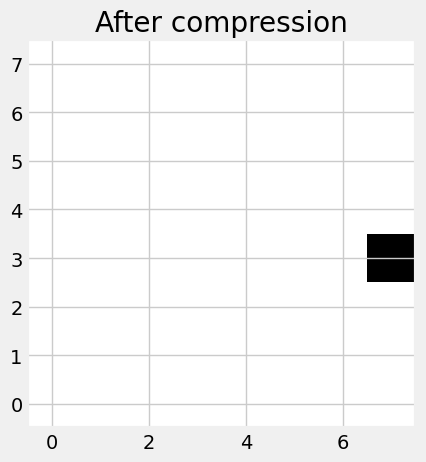

Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 506.06it/s, Loss=0.0356]


Epoch [62/80]Average Loss: BCE = 0.0256, MSE = 7.383309032469076e-05, KL = 3.3986039569030453
Average validation set BCE loss: 0.08931219980120658
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 507.63it/s, Loss=0.0307]


Epoch [63/80]Average Loss: BCE = 0.0256, MSE = 7.307482702349285e-05, KL = 3.399256982995038
Average validation set BCE loss: 0.08971460074186326
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 64/80: 100%|██████████| 199/199 [00:00<00:00, 516.44it/s, Loss=0.024] 


...

Epoch [69/80]Average Loss: BCE = 0.0255, MSE = 6.177795624001251e-05, KL = 3.3898431356228778
Average validation set BCE loss: 0.08571206331253052
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 70/80: 100%|██████████| 199/199 [00:00<00:00, 518.42it/s, Loss=0.029] 


Epoch [70/80]Average Loss: BCE = 0.0255, MSE = 5.897469000686686e-05, KL = 3.389334370742491
Average validation set BCE loss: 0.08846807479858398
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 71/80: 100%|██████████| 199/199 [00:00<00:00, 519.68it/s, Loss=0.0225]


Epoch [71/80]Average Loss: BCE = 0.0255, MSE = 5.846223220987896e-05, KL = 3.3911667241523014
Average validation set BCE loss: 0.08503420576453209
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0179, std=0.8708 | logvar: mean=-6.9896, std=1.0346
Before compression
Shape: (64, 8, 8)


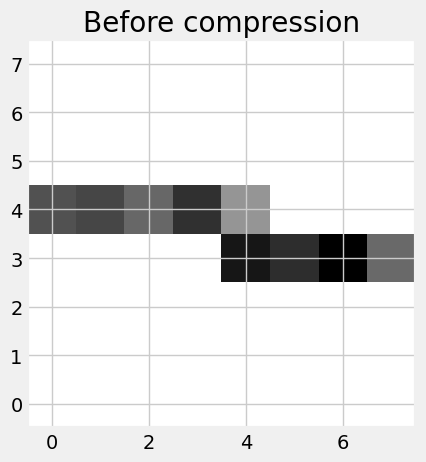

After compression
Shape: (1, 8, 8)


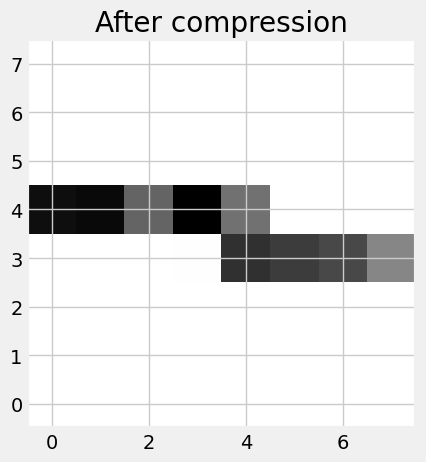

Epoch 72/80: 100%|██████████| 199/199 [00:00<00:00, 513.56it/s, Loss=0.0202]


Epoch [72/80]Average Loss: BCE = 0.0255, MSE = 5.818437139580293e-05, KL = 3.38819484734655
Average validation set BCE loss: 0.08390090271830558
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 73/80: 100%|██████████| 199/199 [00:00<00:00, 523.81it/s, Loss=0.0265]


Epoch [73/80]Average Loss: BCE = 0.0255, MSE = 5.258651550896653e-05, KL = 3.387275976152276
Average validation set BCE loss: 0.08207975581288338
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 74/80: 100%|██████████| 199/199 [00:00<00:00, 527.77it/s, Loss=0.0182]


...

Epoch [78/80]Average Loss: BCE = 0.0254, MSE = 4.865121408141904e-05, KL = 3.3835282074147135
Average validation set BCE loss: 0.08201000057160854
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 517.64it/s, Loss=0.0273]


Epoch [79/80]Average Loss: BCE = 0.0254, MSE = 4.811088393722256e-05, KL = 3.381255231310974
Average validation set BCE loss: 0.08273788534104824
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 516.42it/s, Loss=0.0226]


Epoch [80/80]Average Loss: BCE = 0.0254, MSE = 4.8229258639700526e-05, KL = 3.3802459527499713
Average validation set BCE loss: 0.08032309025526047
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Saving trained model VAE


In [439]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_kl_loss = []

# Patches
patches_before = []
patches_after = []
patches_z = [] # latent vector

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse = []

plot_val_patches_limit = 30
plot_idx = 0

model.train()

for epoch in range(num_epochs):
    train_loss = 0
    train_loss_mse = 0
    kl_loss_total = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            mu,
            logvar,
            _
        ) = model(
           X_adcs
        )
        
        loss, recon_loss, beta, kl_loss = _get_vae_loss(recon_patch, X_adcs, mu, logvar)
        
        recon_patch = recon_patch.float().to(device)      
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        
        train_loss += loss.item()
        kl_loss_total += kl_loss.item()
        
        train_loss_mse += mse(recon_patch, X_adcs).item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_loss_kl = kl_loss_total / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}]"
        f"Average Loss: BCE = {avg_loss_bce:.4f}, "
        f"MSE = {avg_loss_mse}, " 
        f"KL = {avg_loss_kl}"
    )
    
    average_loss_train.append(avg_loss_bce)
    average_loss_train_mse.append(avg_loss_mse)
    average_loss_kl_loss.append(avg_loss_kl)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss = 0
        total_mse_loss = 0
        
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
                recon_patch, 
                mu,
                logvar, 
                z 
            ) = model(patch_val)
            
            total_bce_loss += F.binary_cross_entropy(
                patch_val,
                recon_patch,
                reduction="mean"
            ).cpu().detach().numpy().item()
            
            total_mse_loss += mse(
               patch_val,
               recon_patch  
            ).item()
            
            result = _get_compression_ratio_vae(
                total_hit_amount, 
                patch_amount,
                z
            )
        
        average_loss_val = total_bce_loss / len(val_loader)
        average_loss_val_mse = total_mse_loss / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        print("Last batch patch, compression metrics:")
        for k, v in result.items():
            print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                
                patches_pairs = []
                
                for patch_val in val_loader:
                    patch_val = patch_val.to(device)           
                    
                    (
                        recon_patch, 
                        mu,
                        logvar, 
                        z
                    ) = model(patch_val)
                    
                    if len(patches_pairs) < plot_val_patches_limit:
                        patches_pairs.append((patch_val, z, recon_patch))
                
                print("Last validation batch patch mu and logvar:")
                print(
                    f"mu: mean={mu.mean().item():.4f}, std={mu.std().item():.4f} | "
                    f"logvar: mean={logvar.mean().item():.4f}, std={logvar.std().item():.4f}"
                )
                # print("Loss statistics:")
                # print(
                #     f"recon={recon_loss.item():.4f}, "
                #     f"kl={kl_loss.item():.4f}, " if beta > 0 else ""
                #     f"beta_kl={(beta * kl_loss).item():.4f}" if beta > 0 else ""
                # )
                
                if plot_idx < len(patches_pairs):
                    patch_val_before, z, patch_val_after = patches_pairs[plot_idx]
                    
                    print("Before compression")                    
                    patch_val_ts = _tensor_to_numpy(
                        patch_val_before.squeeze(1)
                    )
                    
                    print(f"Shape: {patch_val_ts.shape}")            
                    plot_patch(patch_val_ts[0], "Before compression")
                    
                    patches_before.append(patch_val_ts[0])
                    
                    recon_patch_np = _tensor_to_numpy(
                        patch_val_after[0]
                    )
                    print("After compression")
                    print(f"Shape: {recon_patch_np.shape}")
                    
                    plot_patch(recon_patch_np[0], "After compression")
                
                    patches_after.append(recon_patch_np[0])  
                    z_np = _tensor_to_numpy(z[0][0])
                    patches_z.append(z_np) 
                    
                    plot_idx += 1        
            
# save model
print("Saving trained model VAE")
torch.save(model.state_dict(), "vae.pth")

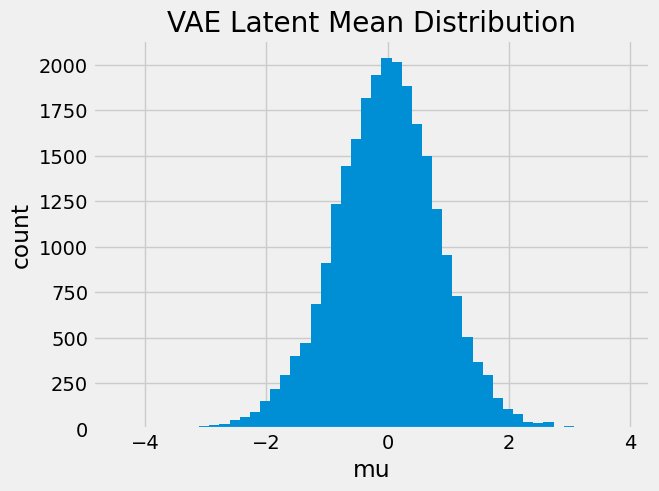

In [440]:
mu_values = mu.detach().cpu().flatten().numpy()
# histogram
plt.hist(mu_values, bins=50)

plt.title("VAE Latent Mean Distribution")
plt.xlabel("mu")
plt.ylabel("count")

plt.show()

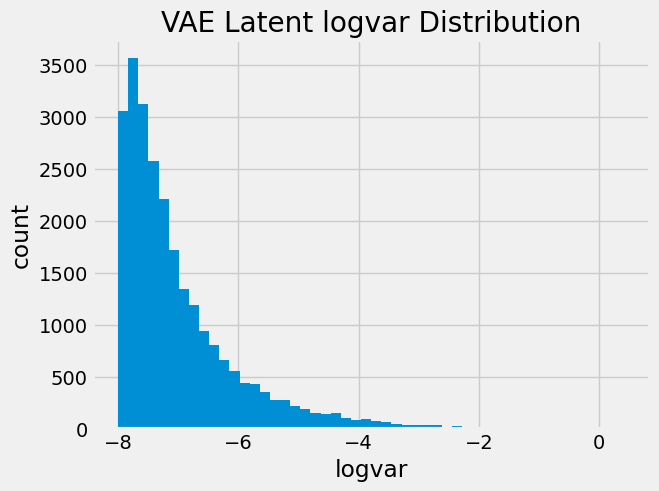

In [441]:
logvar_values = logvar.detach().cpu().flatten().numpy()
# histogram
plt.hist(logvar_values, bins=50)

plt.title("VAE Latent logvar Distribution")
plt.xlabel("logvar")
plt.ylabel("count")

plt.show()

In [442]:
# TODO
# Compression ratio calculation
# Find total sum of hit bits
# Find total sum of encoded patch bits

total_bits = _get_total_hit_bits(total_hit_amount)


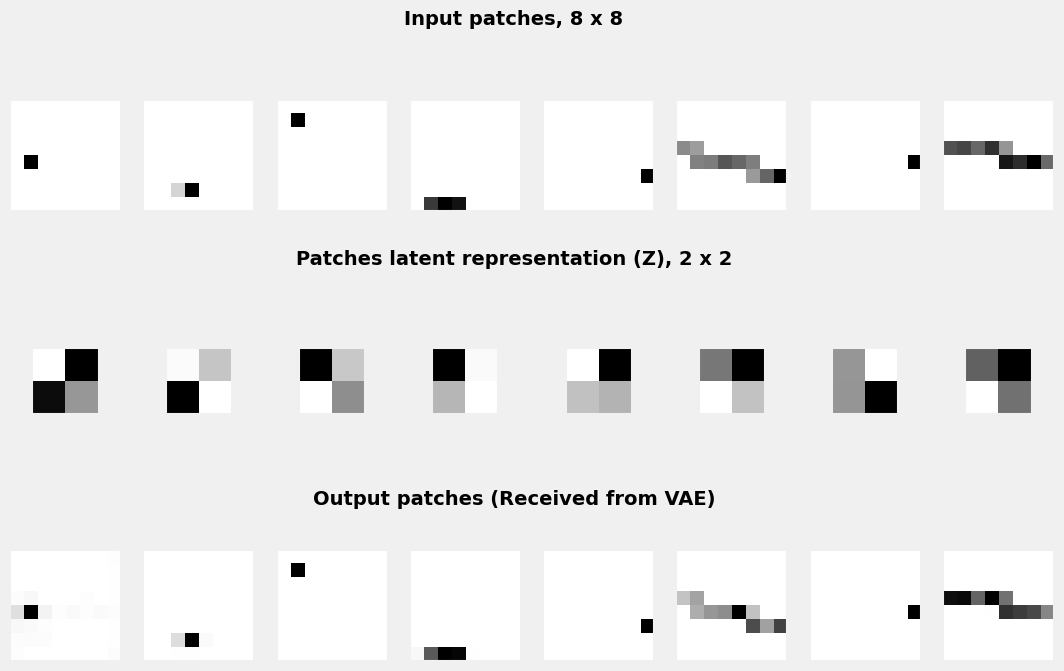

In [443]:
def plot_patches(patch_rows: list[tuple]) -> None:
    cols = len(patch_rows[0][0])
    rows = len(patch_rows)

    # fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
    fig = plt.figure(figsize=(12, 8))
    gs = GridSpec(
        3, cols,
        height_ratios=[1.5, 0.5, 1.5]
    )

    for i in range(rows):
        
        (patch_row, patch_row_title) = patch_rows[i]
        
        fig.text(
            0.5,                    # centered horizontally
            0.92 - i * 0.30,        # vertical position
            patch_row_title,
            ha='center',
            fontsize=14,
            fontweight='bold'
        )
        
        for j in range(cols):
            ax = fig.add_subplot(gs[i, j])
            
            ax.imshow(patch_row[j], cmap='gist_yarg', origin='lower')
            
            ax.set_xticks([])
            ax.set_yticks([])
            
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

        plt.subplots_adjust(wspace=0.2, hspace=0.6)
    plt.show()
        
        
patch_rows = [
    (patches_before, "Input patches, 8 x 8"),
    (patches_z, "Patches latent representation (Z), 2 x 2"),
    (patches_after, "Output patches (Received from VAE)")
]

plot_patches(patch_rows)

In [444]:
len(patch_rows[0][0])

8

In [445]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.006165977101773024
encoder.1.weight 0.0001916195178637281
encoder.1.bias 0.0006206293473951519
encoder.3.weight 0.0018826955929398537
encoder.4.weight 0.00021490620565600693
encoder.4.bias 0.00011833346070488915
encoder.6.weight 0.0018465440953150392
encoder.7.weight 0.00016804694314487278
encoder.7.bias 0.00011593286762945354
fc_mean.weight 0.0008337858598679304
fc_mean.bias 8.249443635577336e-05
fc_log_var.weight 0.0001350007951259613
fc_log_var.bias 1.6157360732904635e-05
decoder.0.weight 0.0014577290276065469
decoder.1.weight 0.0001867853570729494
decoder.1.bias 0.0001232651120517403
decoder.3.weight 0.0035253867972642183
decoder.4.weight 0.000157117290655151
decoder.4.bias 0.00017253206169698387
decoder.6.weight 0.002064748201519251


VAE, Average loss values over epochs


/tmp/ipykernel_381582/3472732.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


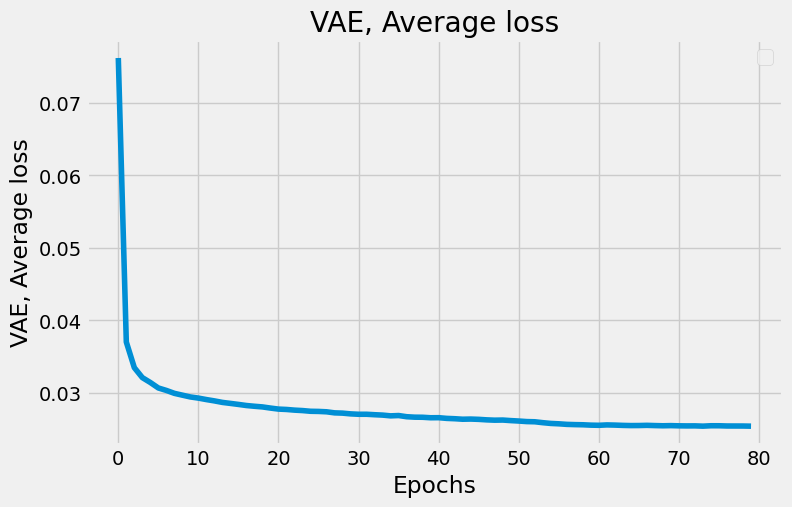

In [446]:
# display loss values
plot_metric_results(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="VAE, Average loss",
    title="VAE, Average loss",
    x_label="Epochs"
)

In [447]:
print(f"mu = {model.z_log_mean.mean().item()}")
print(f"logvar = {model.z_log_var.std().item()}")

mu = -0.02232007123529911
logvar = 1.0283619165420532


In [448]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 8
patches_after_test = []
patches_before_test = []
patches_z = [] # latent vector

bce_total_value = 0

test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        mu,
        logvar,
        z
    ) = model(patch_test)
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        z_np = _tensor_to_numpy(z[0][0])
        
        patches_z.append(z_np)
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="sum"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")

Based on test set (size = 25), average BCE loss = 290.09924


In [449]:
len(patches_before_test)

8

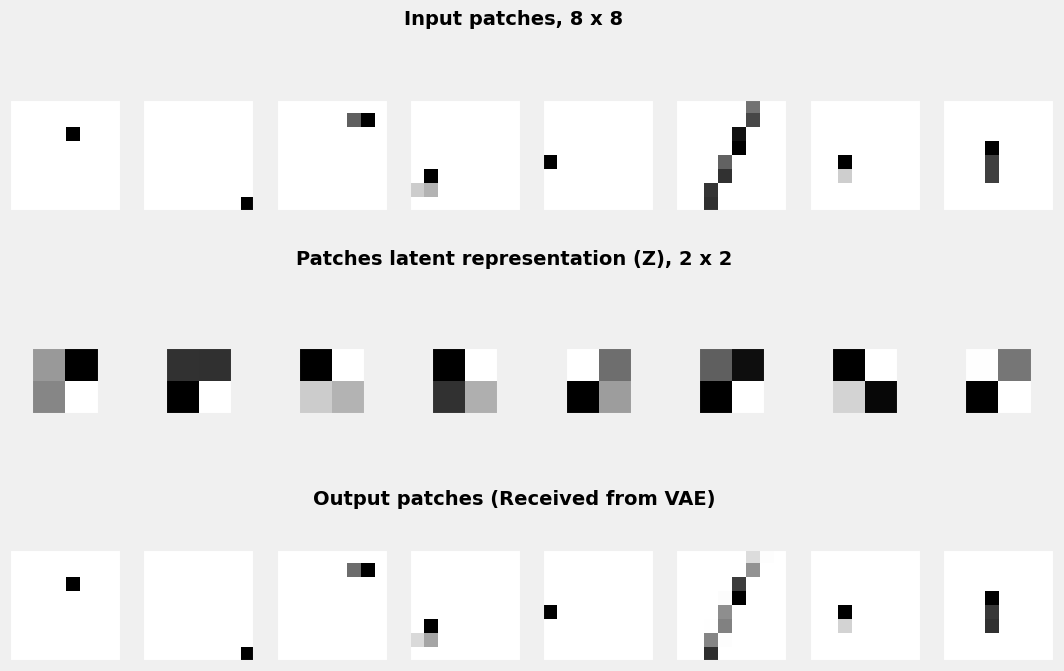

In [450]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_z, "Patches latent representation (Z), 2 x 2"),
    (patches_after_test, "Output patches (Received from VAE)")
]

plot_patches(patch_rows)

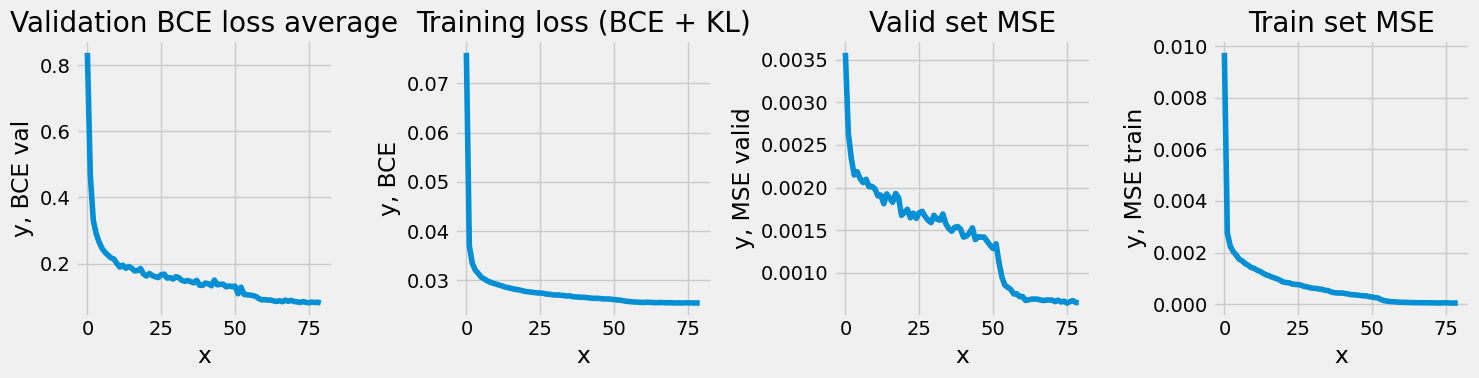

In [451]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + KL)", "BCE"),
    (list(range(len(average_loss_valid_mse))), average_loss_valid_mse, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
]

fig, axes = plt.subplots(1, len(values_to_plot), figsize=(15, 4))

for i, (x, y, title, y_label) in enumerate(values_to_plot):
    axes[i].plot(
        x,
        y,
    )
    axes[i].grid(True)
    axes[i].set_title(title)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"y, {y_label}")
    
    for spine in axes[i].spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# print(title + " values over epochs")
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(x_values, y_values, marker=marker)
# plt.xlabel(x_label)
# plt.ylabel(y_title)
# plt.legend()
# plt.title(title)
# plt.show()

Comments
* Based on the current results,
the closer the Z latent space values are to the prior (Normal distribution),
the less stable VAE model becomes

* The more KL divergence increases, the reconstruction quality significantly drops

* If the reconstruction quality improves, z distribution becomes almost like gaussian and loss function starts to slow down after 5 epochs

* If 10 and -10 extreme values dissapear, then loss does not fall to quickly and reconstruction quality improves

* 10 and -10 extreme values appear due to high learning rate. Lerning_rate = 1e-2

* Since KL divergence is constantly growing, very small beta (scale factor) is required for the KL divergence

* Increase of latent space and hidden dimensions, marginally improved loss function

* Used 0001.root file pixel digi events for forming test, train and validation sets

* Add atleast 1 padding in network layers for preserving signal

* 1 encoded patch latent vector has size 128bits 4 bytes * 4 bytes * 8 bits 

Comment:
Need to use bigger latent dimension. Bigger than 16. Wider latent dimension,
the more information is preserved after matrix transformations
If latent dimension = 16, than noisy outputs from encoder